In [7]:
# Remove nose from image using auto encoder network 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

In [8]:
# Reproducibility
np.random.seed(100)

# Load data
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Reshape to (N, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

# Add Gaussian noise
noise_factor = 0.7
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=.5, size=x_test.shape
)

# Clip to valid range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy, 0., 1.)
x_train_noisy.shape

(60000, 28, 28, 1)

In [9]:
model = Sequential()

# ---------- Encoder ----------
model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                 input_shape=(28, 28, 1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))


model.add(Conv2D(8, (3, 3), activation='relu', padding='same')) # bottleneck 
model.add(Conv2D(8, (3, 3), activation='relu', padding='same')) # deeber bottleneck 

# ---------- Decoder ----------
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))

# Output layer
model.add(Conv2D(1, (3, 3), activation='sigmoid', padding='same',  kernel_initializer='he_normal'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy' #'mean_squared_error'
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 28, 28, 32)        320       
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 14, 14, 16)        4624      
_________________________________________________________________
conv2d_15 (Conv2D)           (None, 14, 14, 16)        2320      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 7, 7, 16)          0         
_________________________________________________________________
conv2d_16 (Conv2D)           (None, 7, 7, 8)          

In [10]:
history = model.fit(
    x_train_noisy, x_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/30
469/469 [==============================] - 9s 17ms/step - loss: 0.1956 - val_loss: 0.1167
Epoch 2/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1377 - val_loss: 0.1037
Epoch 3/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1307 - val_loss: 0.1010
Epoch 4/30
469/469 [==============================] - 8s 17ms/step - loss: 0.1277 - val_loss: 0.0973
Epoch 5/30
469/469 [==============================] - 8s 17ms/step - loss: 0.1258 - val_loss: 0.0974
Epoch 6/30
469/469 [==============================] - 8s 17ms/step - loss: 0.1245 - val_loss: 0.0959
Epoch 7/30
469/469 [==============================] - 8s 17ms/step - loss: 0.1235 - val_loss: 0.0952
Epoch 8/30
469/469 [==============================] - 8s 18ms/step - loss: 0.1226 - val_loss: 0.0936
Epoch 9/30
469/469 [==============================] - 8s 17ms/step - loss: 0.1216 - val_loss: 0.0937
Epoch 10/30
469/469 [==============================] - 8s 17ms/step - loss: 0.1209 - val_lo

In [11]:
decoded_imgs = model.predict(x_test_noisy)

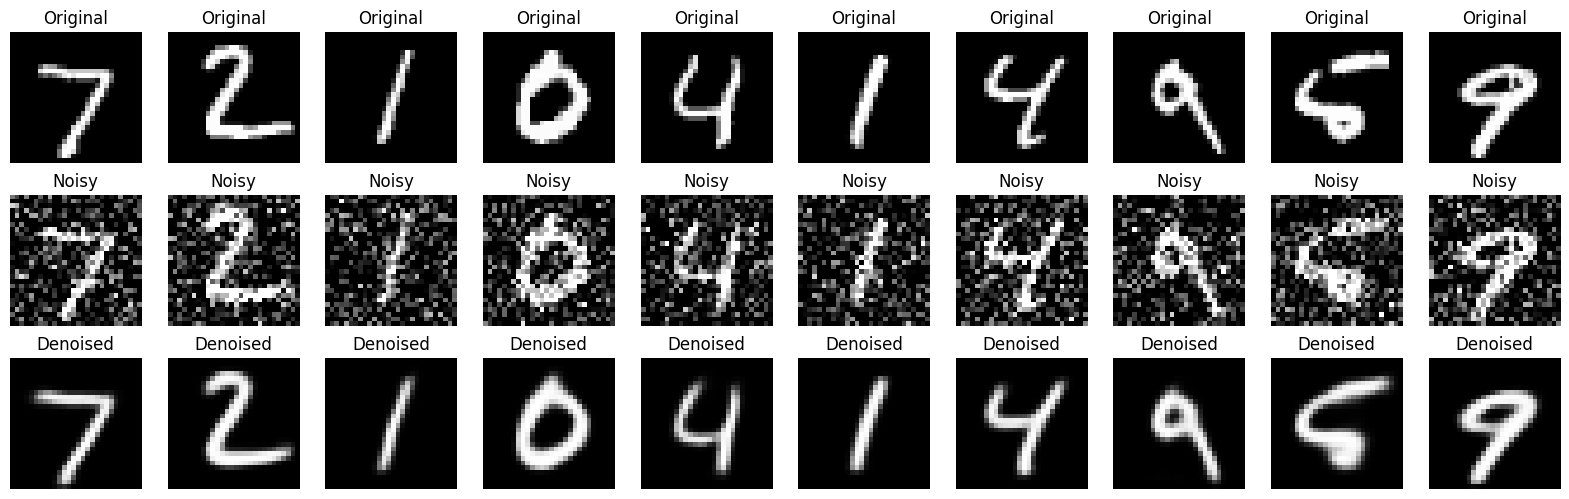

In [12]:
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.show()
